**Iris Flower** **Classification**

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
%matplotlib inline

In [22]:
columns = ['Sepal length', 'Sepal width', 'Petal length', 'Petal width', 'class_labels']
# Load the data
df = pd.read_csv('iris.csv', names=columns)
df.head(150)

,Sepal length,Sepal width,Petal length,Petal width,class_labels
0,sepal.length,sepal.width,petal.length,petal.width,variety
1,5.1,3.5,1.4,.2,Setosa
2,4.9,3,1.4,.2,Setosa
3,4.7,3.2,1.3,.2,Setosa
4,4.6,3.1,1.5,.2,Setosa
...,...,...,...,...,...
145,6.7,3.3,5.7,2.5,Virginica
146,6.7,3,5.2,2.3,Virginica
147,6.3,2.5,5,1.9,Virginica
148,6.5,3,5.2,2,Virginica


In [23]:
df.describe()

,Sepal length,Sepal width,Petal length,Petal width,class_labels
count,151,151,151,151,151
unique,36,24,44,23,4
top,5,3,1.4,.2,Setosa
freq,10,26,13,29,50


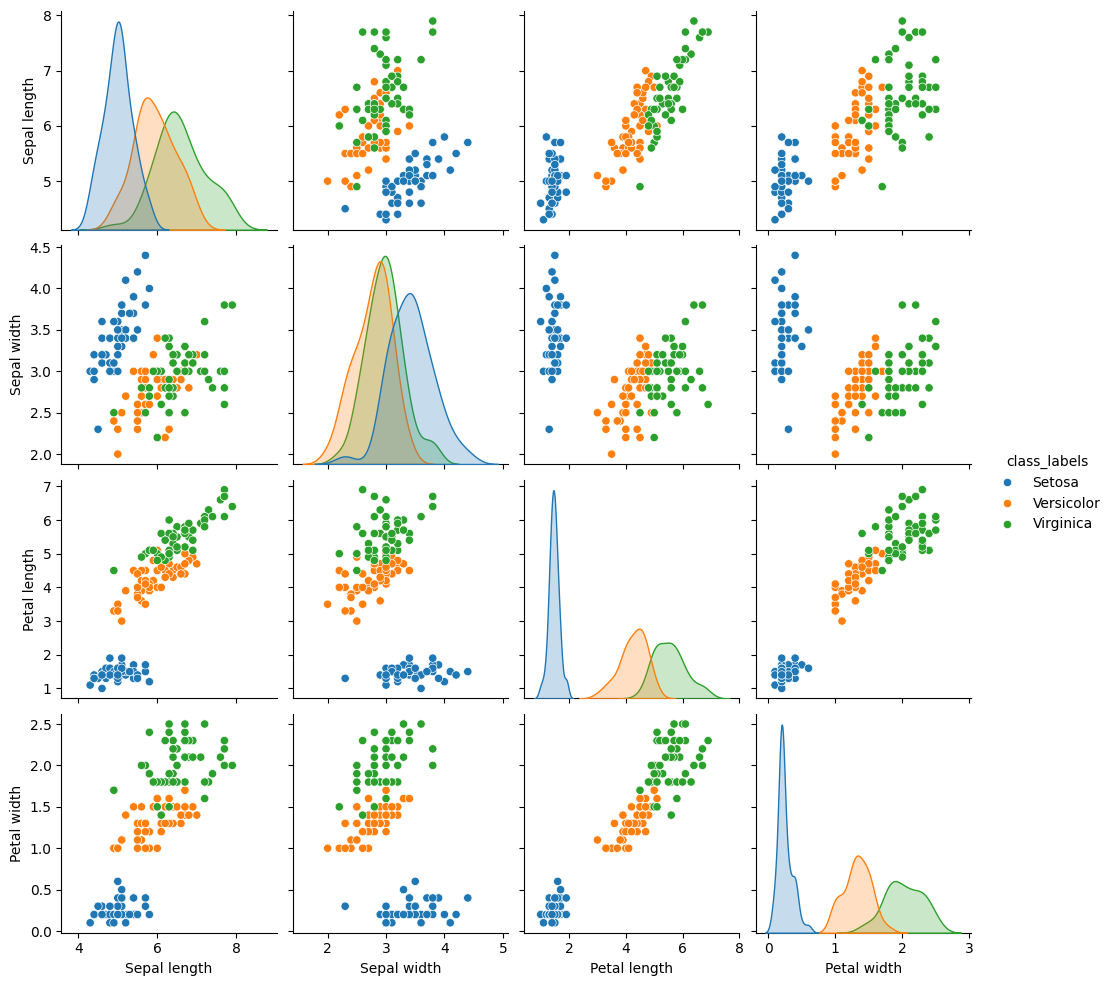

In [24]:
df_numeric = df.iloc[1:].copy()
for col in df_numeric.columns[:-1]:
    df_numeric[col] = pd.to_numeric(df_numeric[col])
sns.pairplot(df_numeric, hue='class_labels')

In [25]:
# Separate features and target
# Use df_numeric which has the header row removed and data converted to numeric
X = df_numeric.iloc[:, :-1].values
Y = df_numeric.iloc[:, -1].values

In [26]:
# Split the data to train and test dataset.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)


MODEL1: Support vector machine algorithm

In [27]:
# Support vector machine algorithm
from sklearn.svm import SVC

model_svc = SVC()
model_svc.fit(X_train, y_train)

SVC()

In [28]:
prediction1 =model_svc.predict(X_test)
# Calculate the accuracy
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, prediction1)*100)

96.66666666666667


In [29]:
#LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression
model_LR=LogisticRegression()
model_LR.fit(X_train,y_train)

LogisticRegression()

In [30]:
prediction2 = model_LR.predict(X_test)
# Calculate the accuracy
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, prediction2)*100)

100.0


In [31]:
# DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
model_DTC=DecisionTreeClassifier()
model_DTC.fit(X_train,y_train)

DecisionTreeClassifier()

In [32]:
prediction3 = model_svc.predict(X_test)
# Calculate the accuracy
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, prediction3)*100)

96.66666666666667


In [33]:
# A detailed classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, prediction2))

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         6
   Virginica       1.00      1.00      1.00        14

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [34]:
X_new = np.array([[3, 2, 1, 0.2], [ 4.9, 2.2, 3.8, 1.1 ], [ 5.3, 2.5, 4.6, 1.9 ]])
#Prediction of the species from the input vector
prediction = model_svc.predict(X_new)
print("Prediction of Species: {}".format(prediction))

Prediction of Species: ['Setosa' 'Versicolor' 'Virginica']
